## This file serves as Data testing module

[] Check how Powerplants are distributed <br/>
[] Add Impact radius <br/>
[] Add Renewability of production as feature

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/global_power_plant_database.csv")
df.head()

,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,fuel1,fuel2,fuel3,...,owner,source,url,geolocation_source,year_of_capacity_data,generation_gwh_2013,generation_gwh_2014,generation_gwh_2015,generation_gwh_2016,estimated_generation_gwh
0,AFG,Afghanistan,Kajaki Hydroelectric Power Plant Afghanistan,GEODB0040538,33.00,32.3220,65.1190,Hydro,NaN,NaN,...,NaN,GEODB,http://globalenergyobservatory.org,GEODB,2017.0,NaN,NaN,NaN,NaN,NaN
1,AFG,Afghanistan,Mahipar Hydroelectric Power Plant Afghanistan,GEODB0040541,66.00,34.5560,69.4787,Hydro,NaN,NaN,...,NaN,GEODB,http://globalenergyobservatory.org,GEODB,2017.0,NaN,NaN,NaN,NaN,NaN
2,AFG,Afghanistan,Naghlu Dam Hydroelectric Power Plant Afghanistan,GEODB0040534,100.00,34.6410,69.7170,Hydro,NaN,NaN,...,NaN,GEODB,http://globalenergyobservatory.org,GEODB,2017.0,NaN,NaN,NaN,NaN,NaN
3,AFG,Afghanistan,Nangarhar (Darunta) Hydroelectric Power Plant ...,GEODB0040536,11.55,34.4847,70.3633,Hydro,NaN,NaN,...,NaN,GEODB,http://globalenergyobservatory.org,GEODB,2017.0,NaN,NaN,NaN,NaN,NaN
4,AFG,Afghanistan,Northwest Kabul Power Plant Afghanistan,GEODB0040540,42.00,34.5638,69.1134,Gas,NaN,NaN,...,NaN,GEODB,http://globalenergyobservatory.org,GEODB,2017.0,NaN,NaN,NaN,NaN,NaN


### Listing all features of the Dataset

In [3]:
list(df.columns)

['country',
 'country_long',
 'name',
 'gppd_idnr',
 'capacity_mw',
 'latitude',
 'longitude',
 'fuel1',
 'fuel2',
 'fuel3',
 'fuel4',
 'commissioning_year',
 'owner',
 'source',
 'url',
 'geolocation_source',
 'year_of_capacity_data',
 'generation_gwh_2013',
 'generation_gwh_2014',
 'generation_gwh_2015',
 'generation_gwh_2016',
 'estimated_generation_gwh']

### Checking the energy mix in globally 

In [6]:
df.groupby("fuel1").agg(
    count = ("fuel1", "size"),
    total_mw=("capacity_mw", "sum")
).reset_index()

,fuel1,count,total_mw
0,Biomass,1290,3.045710e+04
1,Coal,2172,1.860150e+06
2,Cogeneration,43,4.575000e+03
3,Gas,3068,1.179516e+06
4,Geothermal,186,1.255115e+04
5,Hydro,7034,1.045867e+06
6,Nuclear,199,4.086126e+05
7,Oil,2925,4.779718e+05
8,Other,36,2.190100e+03
9,Petcoke,8,4.863000e+02


### Adding the strictly renewable feature for every powerplant without any non renewable fuel

In [ ]:
renewables = {
    "Solar", "Wind", "Hydro", "Geothermal", "Biomass", "Wave and Tidal"
}

df["is_renewable_strict"] = (
    df[["fuel1", "fuel2", "fuel3"]]
    .apply(lambda row: row.dropna().isin(renewables).all(), axis=1)
)

df.groupby("is_renewable_strict").agg(
    count=("fuel1", "size"),
    total_mw=("capacity_mw", "sum")
).reset_index()


,is_renewable_strict,count,total_mw
0,False,9648,3.955104e+06
1,True,19016,1.379197e+06


In [25]:
import plotly.express as px

fig_all = px.scatter_mapbox(
    df,
    lat="latitude",
    lon="longitude",
    color="is_renewable_strict",
    size="capacity_mw",
    zoom=1,
    height=650,
    hover_data={
        "is_renewable_strict": True,
        "capacity_mw": True,
        "fuel1": True,
    },
)

fig_all.update_layout(
    mapbox_style="carto-positron",  # kein API Key nötig
    margin=dict(l=10, r=10, t=60, b=10),
    title="All Power Plants Globally"
)

fig_all.show()

/var/folders/jn/_v6d9cfx10jcy9jrr4cth92c0000gn/T/ipykernel_15515/2825169016.py:3: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig_all = px.scatter_mapbox(


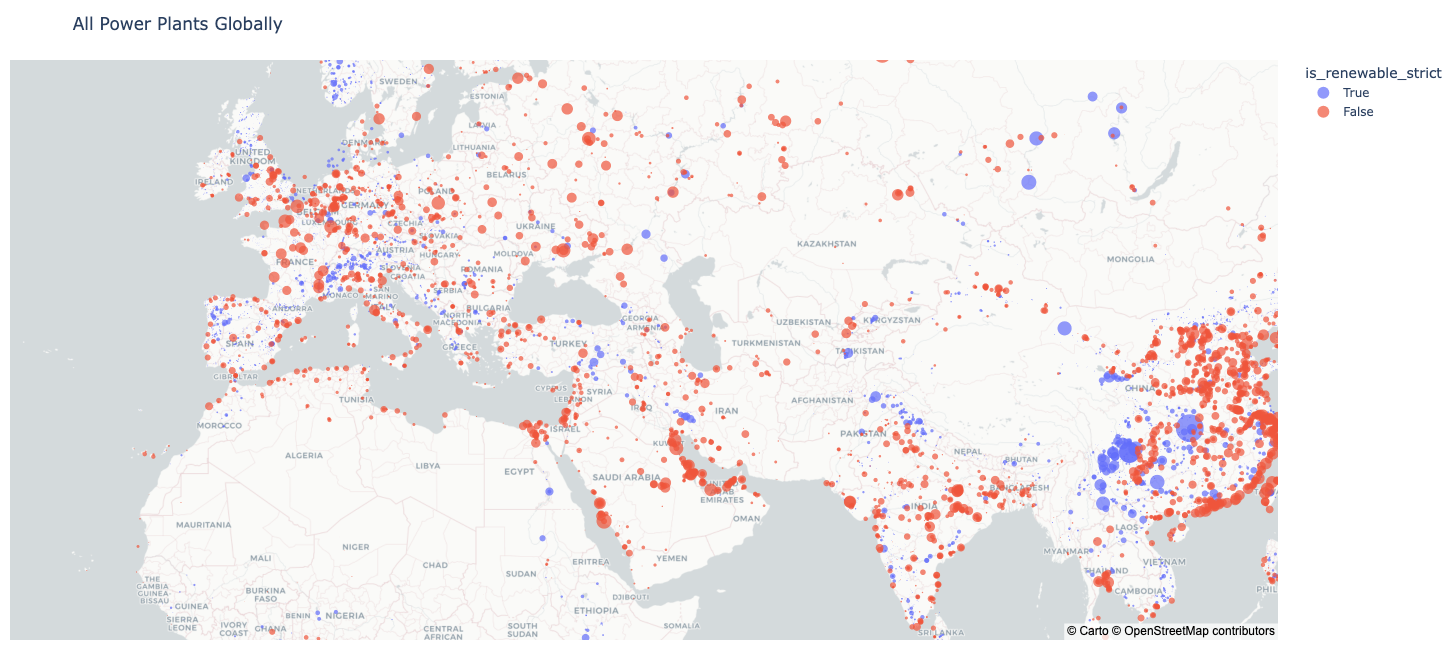

In [26]:
df.to_csv("../data/all_power_plants_clean.csv")